### Import

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Suppress warnings
Configure the warnings module to ignore non‑critical warnings.

In [4]:
import warnings

warnings.filterwarnings("ignore")

### Pull dataset and anomalies from database

In [5]:
df = pd.read_csv("onlinefraud.csv")
df = df.drop(columns= "isFlaggedFraud")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


## Exploratory Data Analysis (EDA)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 657.7 MB


In [39]:
df.shape

(6362620, 10)

In [40]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

- The dataset contains no missing values

In [41]:
df.duplicated().sum()

np.int64(0)

- No duplicate transactions were found in the dataset.

In [4]:
# Use smaller dtype for numberical columns
for col in df.columns:
    if df[col].dtype == 'float64':
        df[col] = pd.to_numeric(df[col], downcast= 'float')
    if df[col].dtype == 'int64':
        df[col] = pd.to_numeric(df[col], downcast= 'unsigned')
        
df['type'] = df['type'].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            uint16  
 1   type            category
 2   amount          float64 
 3   nameOrig        str     
 4   oldbalanceOrg   float64 
 5   newbalanceOrig  float64 
 6   nameDest        str     
 7   oldbalanceDest  float64 
 8   newbalanceDest  float64 
 9   isFraud         uint8   
dtypes: category(1), float64(5), str(2), uint16(1), uint8(1)
memory usage: 491.3 MB


In [43]:
df.describe(include= [np.number]).T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [44]:
df.describe(include= ['str', 'category']).T

,count,unique,top,freq
type,6362620,5,CASH_OUT,2237500
nameOrig,6362620,6353307,C2098525306,3
nameDest,6362620,2722362,C1286084959,113


In [45]:
df['nameOrig'].value_counts()

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
              ..
C786484425     1
C1529008245    1
C1162922333    1
C1685995037    1
C1280323807    1
Name: count, Length: 6353307, dtype: int64

- There are 6,353,307 unique customers initiating transactions.

In [46]:
df['nameDest'].value_counts()

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
              ... 
C1812552860      1
C1470998563      1
C1850423904      1
C1881841831      1
C2080388513      1
Name: count, Length: 2722362, dtype: int64

- There are 2,722,362 unique transaction recipients.

In [47]:
for i in df.select_dtypes(include= "category").columns:
    print(df[i].value_counts())
    print("***" * 10)

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64
******************************


### Graphs

In [48]:
# Setting
sns.set_style('whitegrid')

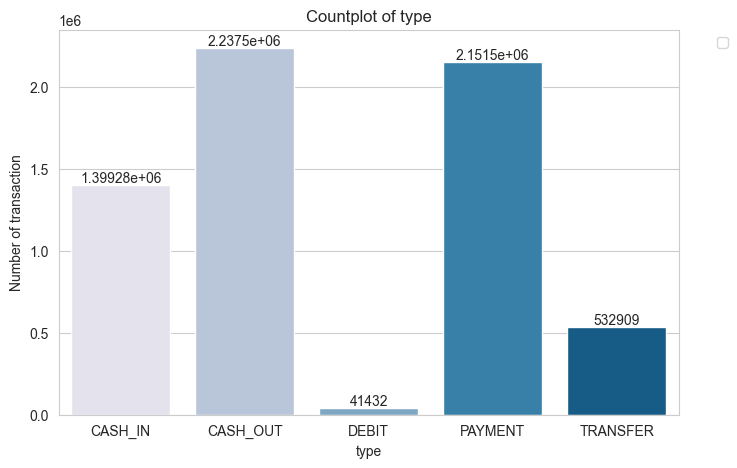

In [49]:
col = 'type'

plt.figure(figsize=(8, 5))

ax = sns.countplot(x=col, data=df, palette= 'PuBu')

for container in ax.containers:
    ax.bar_label(container)

# plt.grid(axis='y', alpha= 0.5)
plt.title(f'Countplot of {col}')
plt.ylabel('Number of transaction')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

- Cash Out is the most frequent transaction type, followed by Payment, Cash In, Transfer, and Debit.

In [14]:
numberic_cols = df.select_dtypes(include= 'number').columns
numberic_cols

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'hour_of_day', 'is_Merchant_Dest',
       'errorBalanceOrig', 'errorBalanceDest'],
      dtype='str')

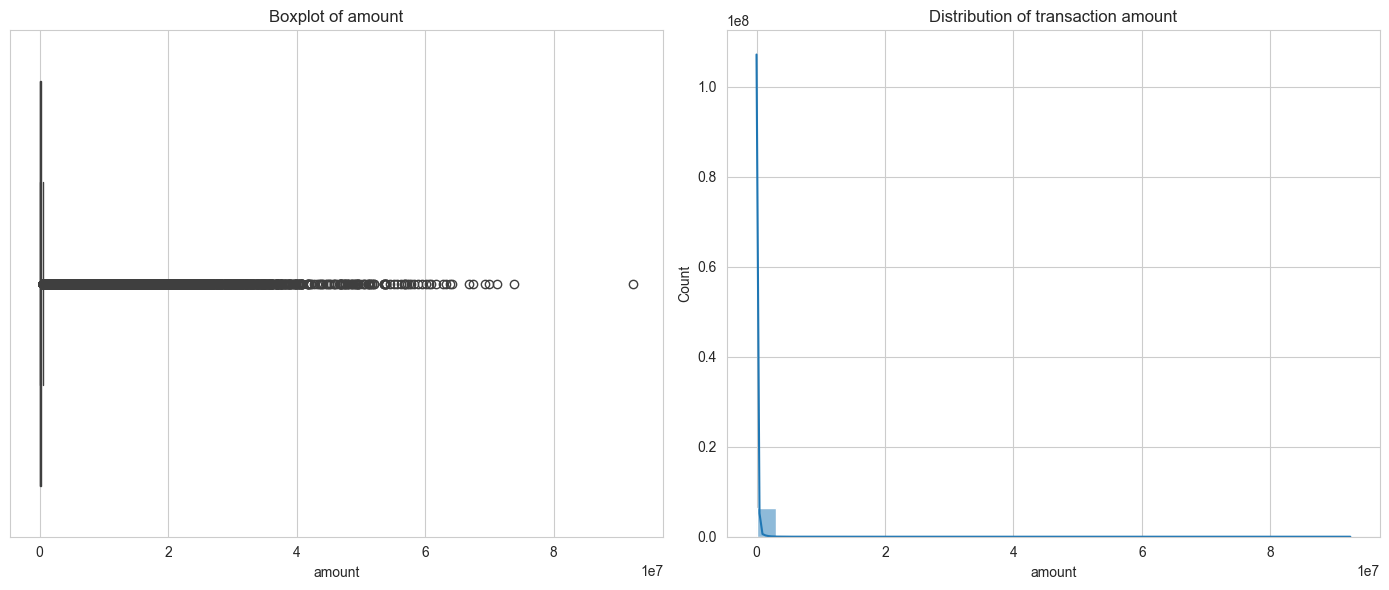

In [51]:
col = 'amount'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- Most transactions occur with relatively low transaction amounts.

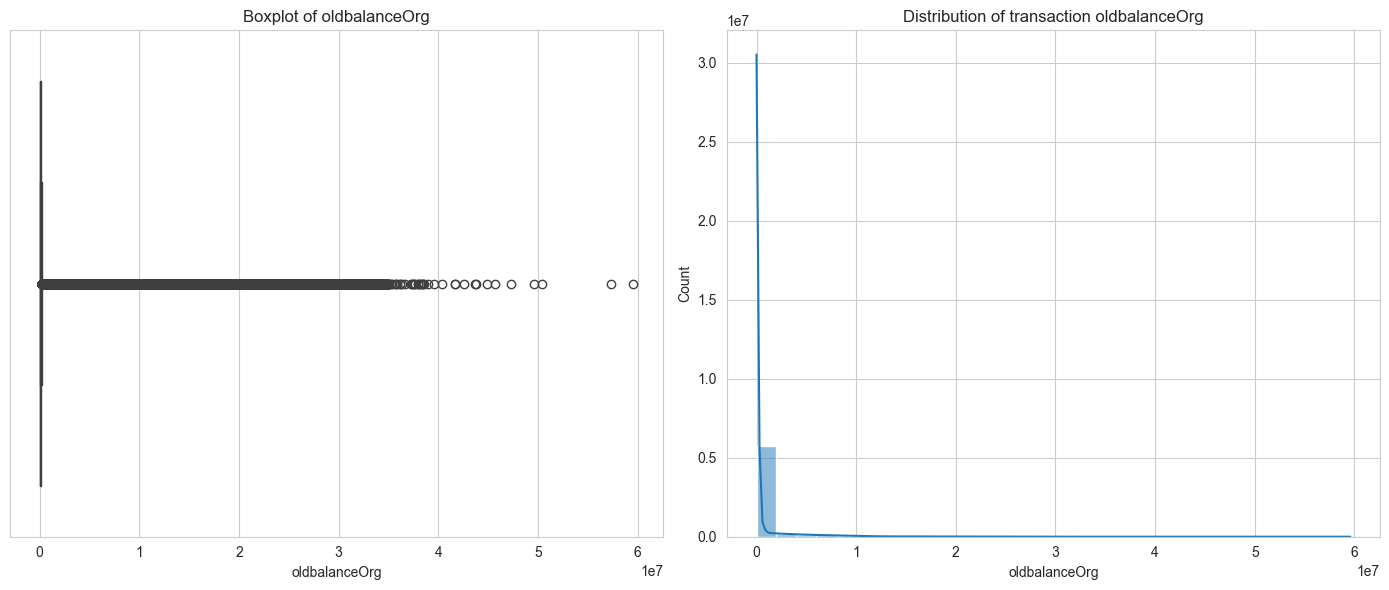

In [52]:
col = 'oldbalanceOrg'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- The distribution of customer balances before transactions is heavily right-skewed.

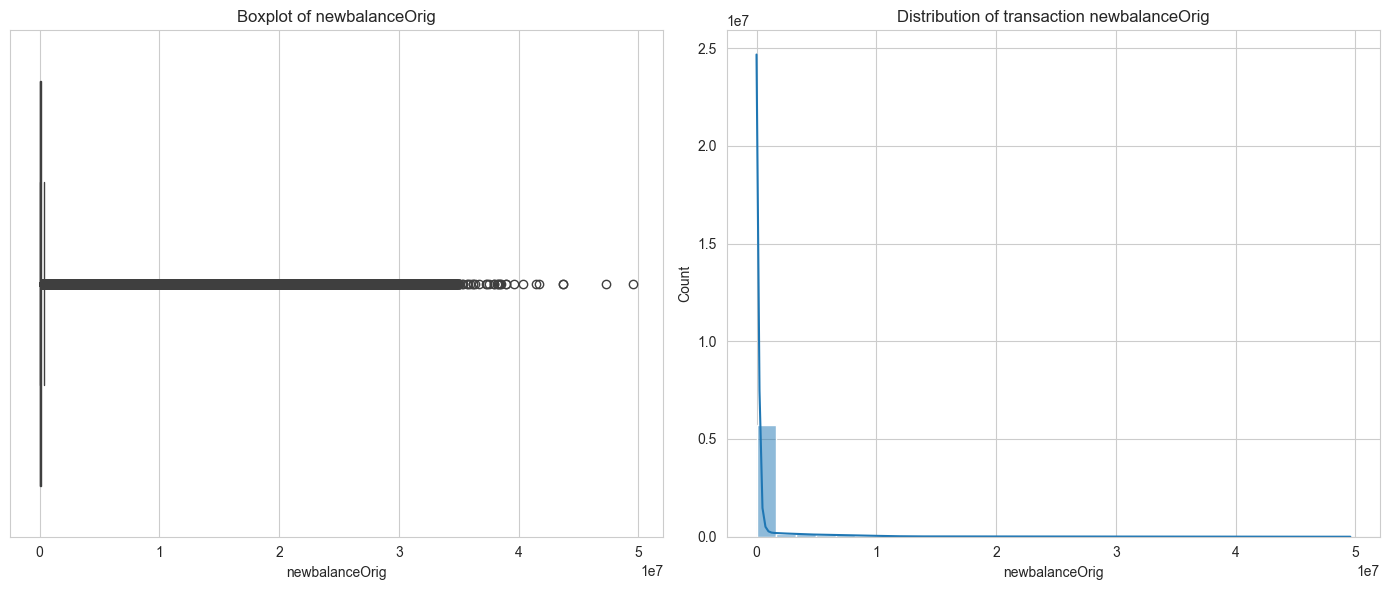

In [53]:
col = 'newbalanceOrig'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- The distribution of customer balances after transactions is highly right-skewed.

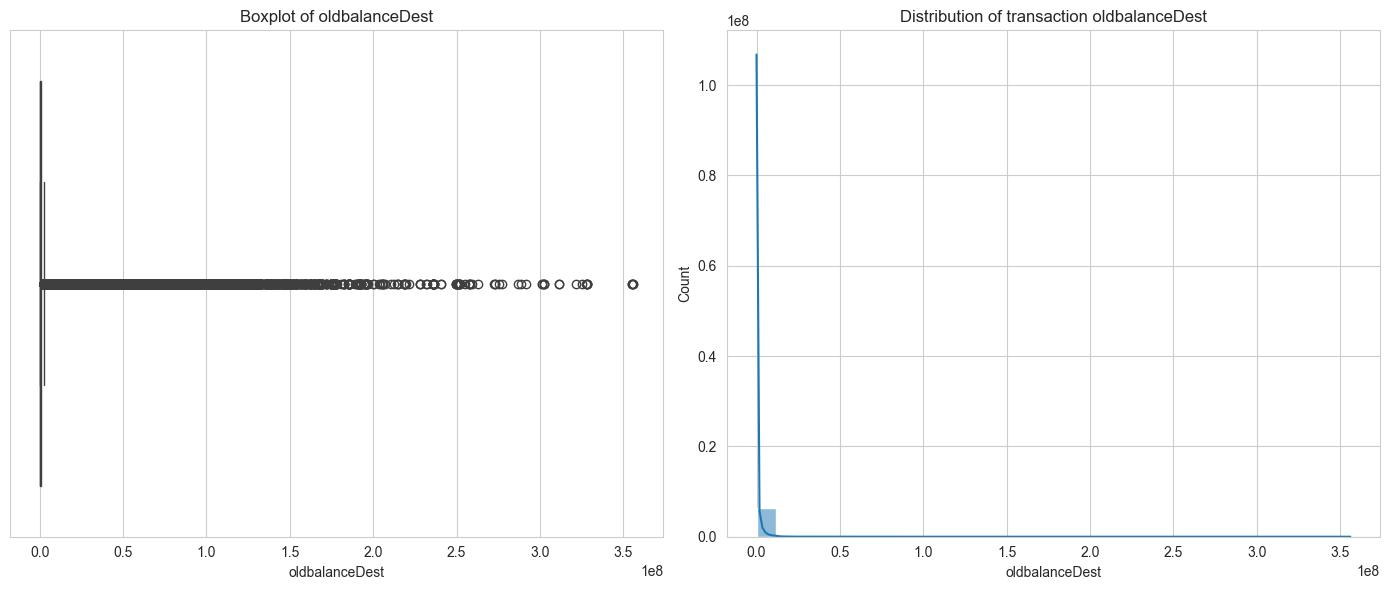

In [54]:
col = 'oldbalanceDest'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- The distribution of recipient balances before transactions is highly right-skewed.

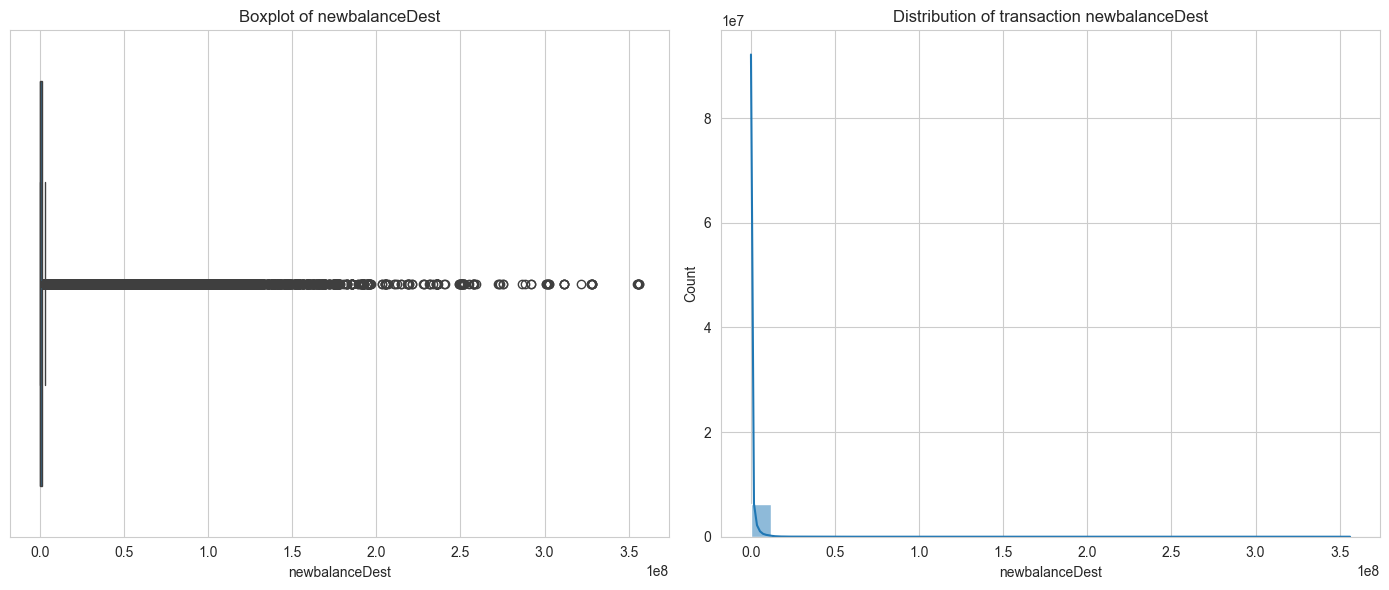

In [55]:
col = 'newbalanceDest'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- The distribution of recipient balances after transactions is highly right-skewed.

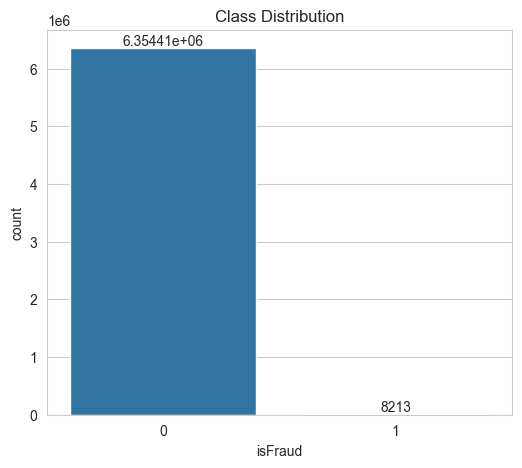

Class counts (0: Non-Fraud, 1: Fraud)
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [56]:
col = 'isFraud'

plt.figure(figsize=(6, 5))

ax = sns.countplot(x=df[col])

for container in ax.containers:
    ax.bar_label(container)

plt.title('Class Distribution')
plt.show()

print('Class counts (0: Non-Fraud, 1: Fraud)')
print(df[col].value_counts())

- The dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of all transactions.

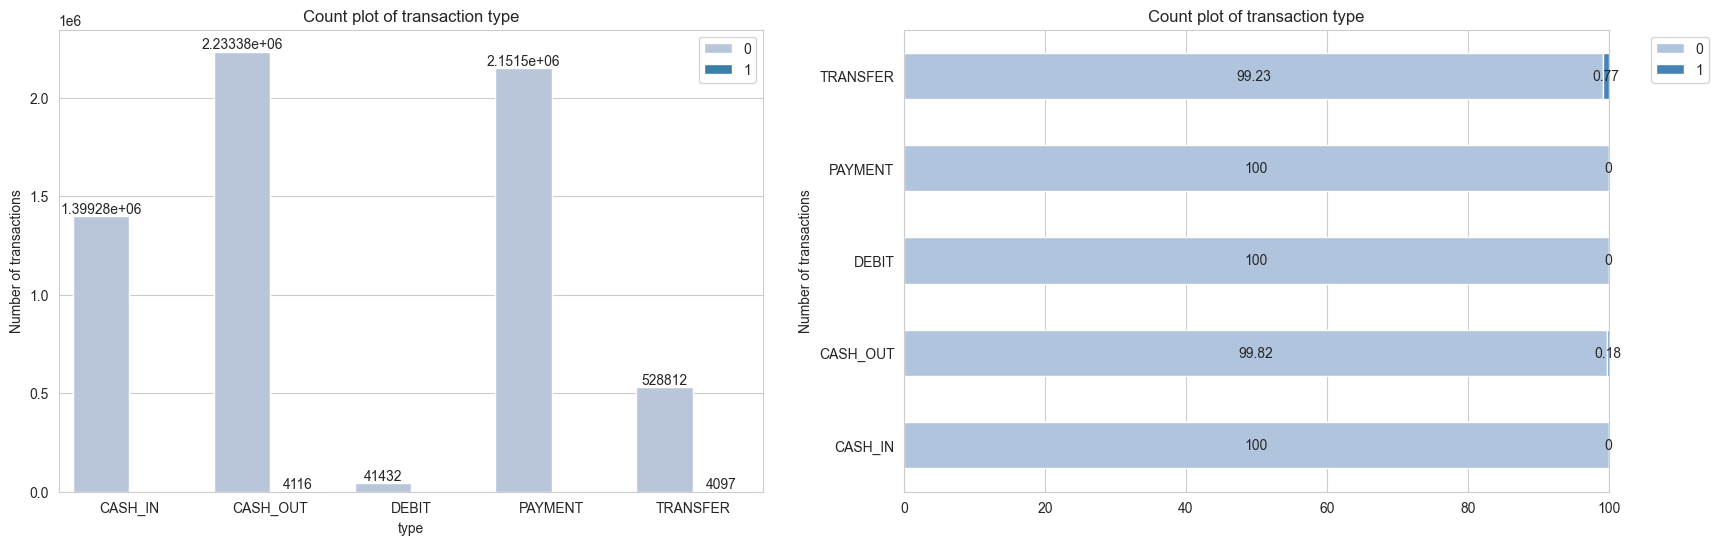

In [57]:
fig, ax = plt.subplots(1,2,figsize=(20,6))

sns.countplot(x='type', data=df, hue='isFraud', palette='PuBu', ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container)
ax[0].set_title('Count plot of transaction type')
ax[0].legend(loc='best')
ax[0].set_ylabel('Number of transactions')

df2 = df.groupby(['type', 'isFraud']).size().unstack(fill_value= 0)
df2.apply(lambda x : round(x/sum(x)*100, 2), axis=1).plot(kind='barh', stacked=True, color=['lightsteelblue', 'steelblue'], ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, label_type='center')
ax[1].set_title('Count plot of transaction type')
ax[1].legend(bbox_to_anchor=(1.05,1), loc='upper left')
ax[1].set_ylabel('Number of transactions')
ax[1].grid(axis='y')

- Fraudulent transactions occur primarily in Transfer and Cash Out transaction types.

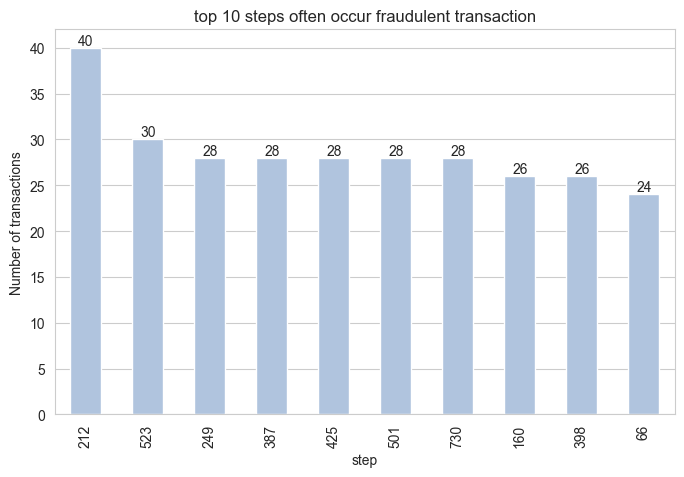

In [58]:
df1 = df[df['isFraud'] == 1]
df2 = df1['step'].value_counts().head(10)

plt.figure(figsize= (8,5))
ax = df2.plot(kind= 'bar', color= 'lightsteelblue')

for container in ax.containers:
    ax.bar_label(container)

plt.title('top 10 steps often occur fraudulent transaction')
plt.ylabel("Number of transactions")
plt.grid(axis= 'x')
plt.show()

- Step 212 contains the highest number of fraudulent transactions, with 40 recorded cases.

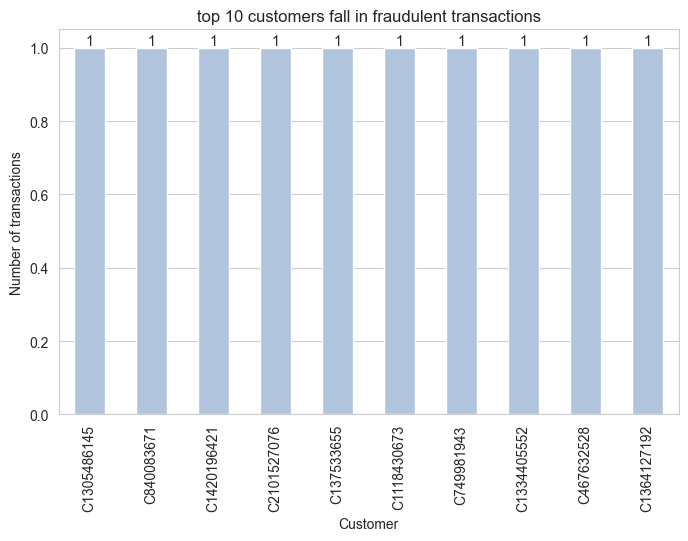

In [59]:
df2 = df1['nameOrig'].value_counts().head(10)
plt.figure(figsize= (8,5))
ax = df2.plot(kind= 'bar', color= 'lightsteelblue')

for container in ax.containers:
    ax.bar_label(container)

plt.title('top 10 customers fall in fraudulent transactions')
plt.ylabel("Number of transactions")
plt.xlabel("Customer")
plt.grid(axis= 'x')
plt.show()

- Most customers appear in fraudulent transactions only once.

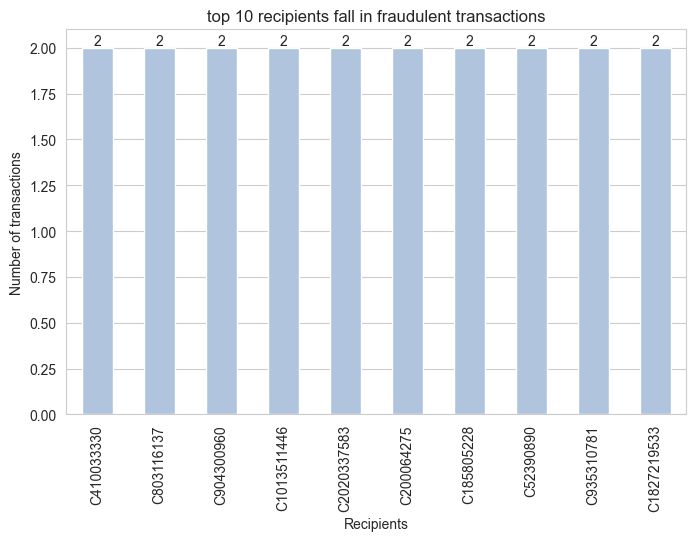

In [60]:
df2 = df1['nameDest'].value_counts().head(10)
plt.figure(figsize= (8,5))
ax = df2.plot(kind= 'bar', color= 'lightsteelblue')

for container in ax.containers:
    ax.bar_label(container)

plt.title('top 10 recipients fall in fraudulent transactions')
plt.xlabel("Recipients")
plt.ylabel("Number of transactions")
plt.grid(axis= 'x')
plt.show()

- Most fraudulent recipients are associated with transactions involving at most two customers.

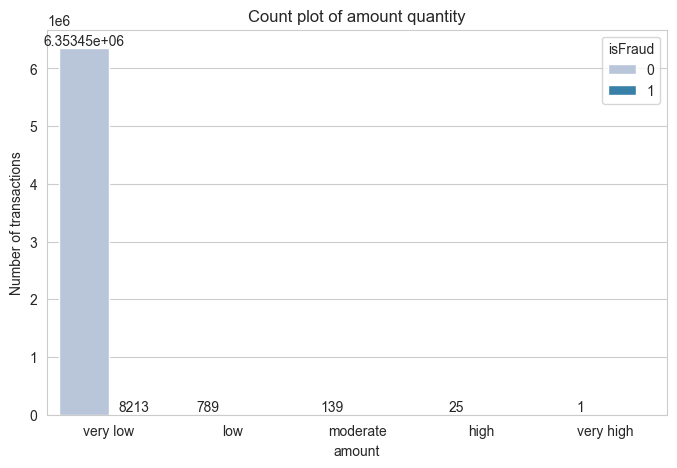

In [61]:
df['quantity'] = pd.cut(df['amount'], 5, labels= ['very low', 'low', 'moderate', 'high', 'very high'])

plt.figure(figsize= (8,5))

ax = sns.countplot(data= df, x= 'quantity', hue= 'isFraud', palette= 'PuBu')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Count plot of amount quantity')
plt.xlabel('amount')
plt.ylabel('Number of transactions')
plt.show()

- Most fraudulent transactions occur within the very low transaction amount range.

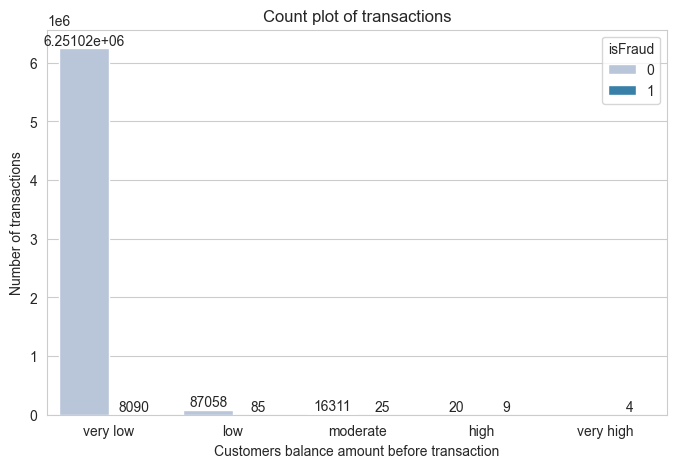

In [ ]:
df['oldbalanceOrg_amount'] = pd.cut(df['oldbalanceOrg'], 5, labels= ['very low', 'low', 'moderate', 'high', 'very high'])

plt.figure(figsize= (8,5))

ax = sns.countplot(data= df, x= 'oldbalanceOrg_amount', hue= 'isFraud', palette= 'PuBu')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Count plot of Customers balance amount before transaction')
plt.xlabel('Customers balance amount before transaction')
plt.ylabel('Number of transactions')
plt.show()

- Customers with very low account balances are associated with the highest number of fraudulent transactions.

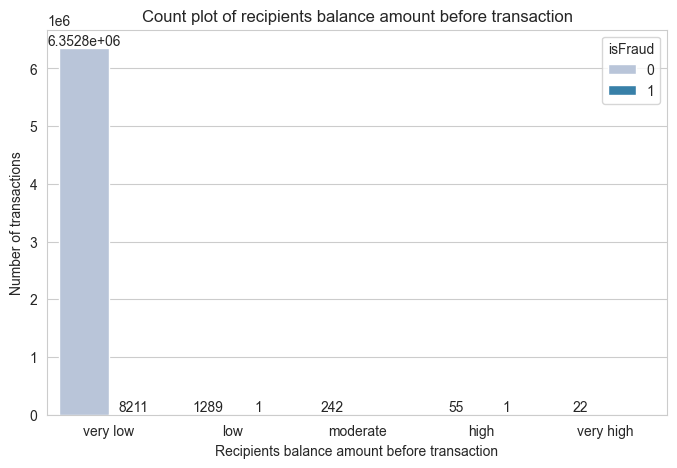

In [63]:
df['oldbalanceDest_amount'] = pd.cut(df['oldbalanceDest'], 5, labels= ['very low', 'low', 'moderate', 'high', 'very high'])

plt.figure(figsize= (8,5))

ax = sns.countplot(data= df, x= 'oldbalanceDest_amount', hue= 'isFraud', palette= 'PuBu')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Count plot of recipients balance amount before transaction')
plt.xlabel('Recipients balance amount before transaction')
plt.ylabel('Number of transactions')
plt.show()

- Most fraudulent recipients have very low account balances.

### Multivariate data visualization

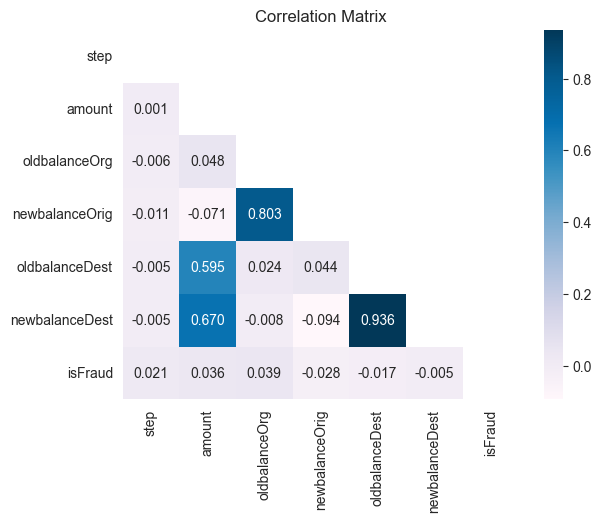

In [64]:
corr = df[numberic_cols].corr('spearman')
sns.heatmap(corr, cbar= True, annot=True, fmt='.3f', cmap= 'PuBu', mask= np.triu(np.ones_like(corr, dtype= bool)))
plt.grid(False)
plt.title('Correlation Matrix')
plt.show()

- oldbalanceOrg and newbalanceOrig show a **strong positive** correlation.
- newbalanceDest and oldbalanceDest exhibit a **strong positive** correlation.
- amount has a **moderate positive** correlation with oldbalanceDest and newbalanceDest.
- amount has a **weak positive** correlation with oldbalanceOrg.

In [6]:
df['hour_of_day'] = df['step'] % 24

df['is_Merchant_Dest'] = df['nameDest'].str.startswith('M').astype(int)

df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']

df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df.loc[df['is_Merchant_Dest'] == 1, 'errorBalanceDest'] = 0

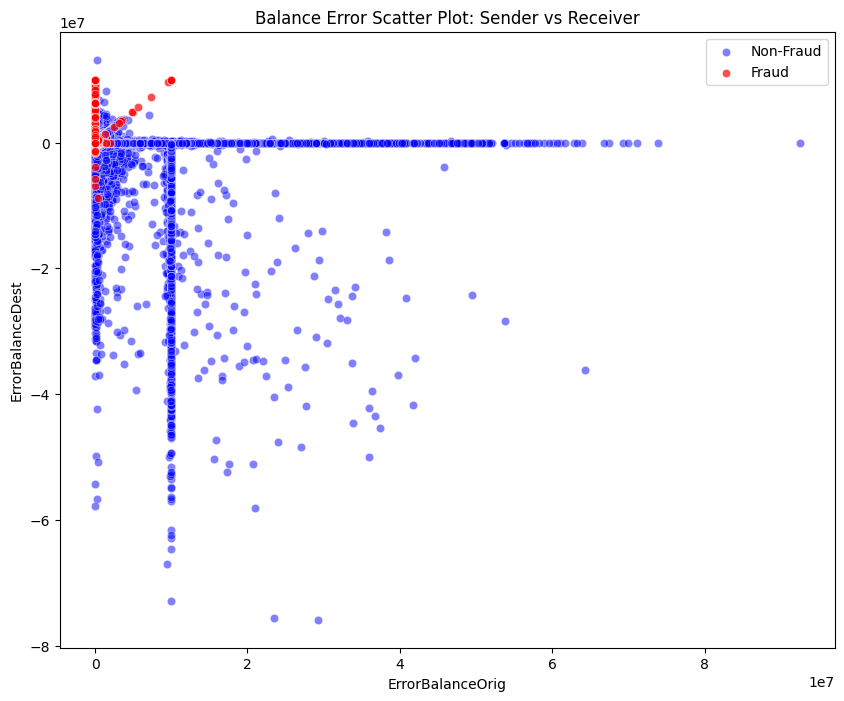

In [ ]:
plt.figure(figsize=(20, 16))

# Vẽ giao dịch hợp lệ 
sns.scatterplot(data=df[df['isFraud'] == 0], 
                x='errorBalanceOrig', y='errorBalanceDest', 
                color='blue', label='Non-Fraud', alpha=0.5)

# Vẽ giao dịch lừa đảo (vẽ tất cả)
sns.scatterplot(data=df[df['isFraud'] == 1], 
                x='errorBalanceOrig', y='errorBalanceDest', 
                color='red', label='Fraud', alpha=0.7)

plt.title('Balance Error Scatter Plot: Sender vs Receiver')
plt.xlabel('ErrorBalanceOrig')
plt.ylabel('ErrorBalanceDest')
plt.legend()
plt.show()

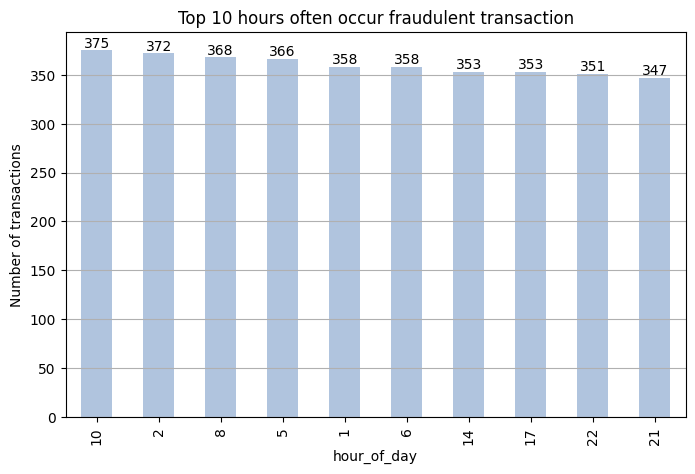

In [14]:
df1 = df[df['isFraud'] == 1]
df2 = df1['hour_of_day'].value_counts().head(10)

plt.figure(figsize= (8,5))
ax = df2.plot(kind= 'bar', color= 'lightsteelblue')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Top 10 hours often occur fraudulent transaction')
plt.ylabel("Number of transactions")
plt.grid(axis= 'y')
plt.show()

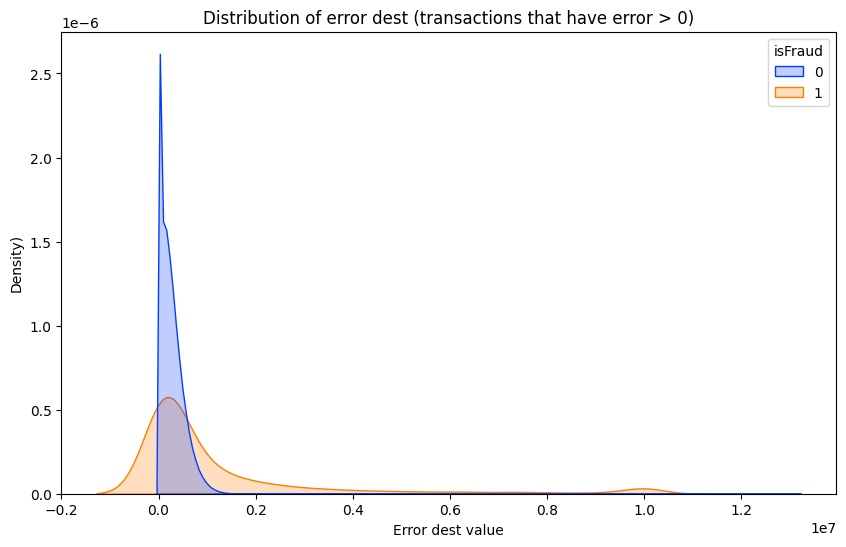

In [15]:
error_dest_df = df[df['errorBalanceDest'] > 0]

plt.figure(figsize=(10, 6))
sns.kdeplot(data=error_dest_df, x='errorBalanceDest', hue='isFraud', 
            common_norm=False, fill=True, palette='bright')

plt.title('Distribution of error dest (transactions that have error > 0)')
plt.xlabel('Error dest value')
plt.ylabel('Density)')
plt.show()

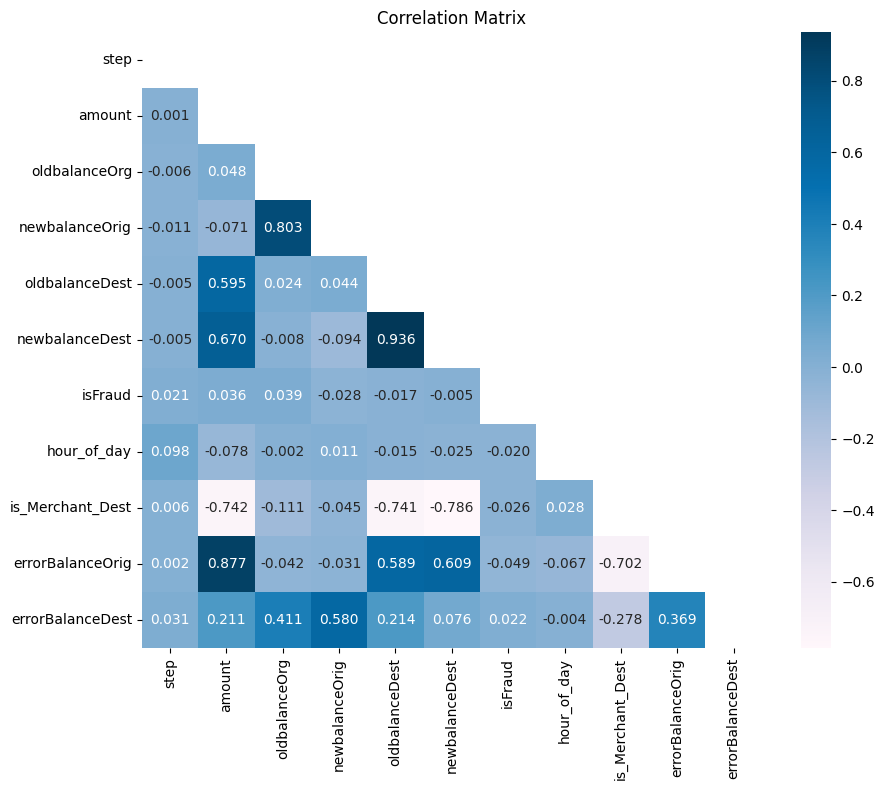

In [19]:
corr = df[numberic_cols].corr('spearman')
plt.figure(figsize= (10, 8))
sns.heatmap(corr, cbar= True, annot=True, fmt='.3f', cmap= 'PuBu', mask= np.triu(np.ones_like(corr, dtype= bool)))
plt.grid(False)
plt.title('Correlation Matrix')
plt.show()

## Preprocessing

In [20]:
# df.drop(['quantity', 'oldbalanceOrg_amount', 'oldbalanceDest_amount'], axis=1, inplace=True)
df = pd.get_dummies(data= df, columns=['type'], dtype= 'int', drop_first= True)
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour_of_day,is_Merchant_Dest,errorBalanceOrig,errorBalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,1,1,0.0,0.0,0,0,1,0
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,1,1,0.0,0.0,0,0,1,0
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,1,0,0.0,181.0,0,0,0,1
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,1,0,0.0,21363.0,1,0,0,0
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,1,1,0.0,0.0,0,0,1,0


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

X = df.drop(['nameOrig', 'nameDest'], axis= 1)
y = X.pop('isFraud')

# Split data
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

# Apply undersampling ONLY on training data
# rus = RandomUnderSampler(random_state=42)

# x_train_resampled, y_train_resampled = rus.fit_resample(
#     x_train,
#     y_train
# )

# Apply SMOTE ONLY on training data
# smote = SMOTE(random_state=42)

# x_train_resampled, y_train_resampled = smote.fit_resample(
#     x_train,
#     y_train
# )

In [44]:
# Keep only 1 million rows
# Sample for model comparison
X_sample, _, y_sample, _ = train_test_split(
    x_train,
    y_train,
    train_size=1_000_000,
    stratify=y_train,
    random_state=42
)

X_sample.shape, y_sample.shape

((1000000, 14), (1000000,))

In [45]:
x_train.shape, x_test.shape

((5090096, 14), (1272524, 14))

In [46]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score

def model_comparison_evaluate(classifiers, X, y, n_splits=5):
    """
    Compare multiple classification models using Stratified K-Fold Cross Validation.

    Parameters
    ----------
    classifiers : dict
        Dictionary containing model names and model objects.

        Example:
        {
            'Logistic Regression': LogisticRegression(),
            'Random Forest': RandomForestClassifier()
        }

    X : pandas.DataFrame, pandas.Series, numpy.ndarray
        Feature matrix (input variables).

        Accepted formats:
        - pandas DataFrame
        - pandas Series
        - NumPy array

        Shape:
        (n_samples, n_features)

    y : pandas.Series, numpy.ndarray, list
        Target labels.

        Accepted formats:
        - pandas Series
        - NumPy array
        - Python list

        Shape:
        (n_samples,)

    n_splits : int, default=5
        Number of folds for cross-validation.

    Returns
    -------
    None
        Prints evaluation results for each model.
    """

    # Stratified K-Fold keeps class distribution balanced
    skfold = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    # PR-AUC scorer
    pr_auc_scorer = make_scorer(
        average_precision_score,
        response_method='predict_proba'
    )

    scoring_metrics = {
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
        'pr_auc': pr_auc_scorer
    }

    print('K-Fold Cross-Validation Evaluation\n')

    for name, model in classifiers.items():

        print('=' * 50)
        print(f'Model: {name}')
        print('=' * 50)

        for metric_name, scoring_method in scoring_metrics.items():

            scores = cross_val_score(
                estimator=model,
                X=X,
                y=y,
                scoring=scoring_method,
                cv=skfold,
                n_jobs= -1
            )

            print(
                f'{metric_name:<10}: '
                f'Mean = {scores.mean():.4f} | '
                f'Std = {scores.std():.4f}'
            )

        print('\n')

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

classifiers = {

    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        learning_rate=0.1,
        max_iter=200,
        max_depth=10,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=10,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        objective='binary',
        random_state=42,
    ),

    'CatBoost': CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=10,
        loss_function='Logloss',
        eval_metric='AUC',
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0,
    )
}

In [48]:
model_comparison_evaluate(classifiers, X_sample, y_sample)

K-Fold Cross-Validation Evaluation

Model: Logistic Regression
precision : Mean = 0.0270 | Std = 0.0018
recall    : Mean = 0.9504 | Std = 0.0113
f1        : Mean = 0.0525 | Std = 0.0034
roc_auc   : Mean = 0.9881 | Std = 0.0023
pr_auc    : Mean = 0.5893 | Std = 0.0154


Model: Random Forest
precision : Mean = 0.9992 | Std = 0.0016
recall    : Mean = 0.9930 | Std = 0.0045
f1        : Mean = 0.9961 | Std = 0.0021
roc_auc   : Mean = 0.9973 | Std = 0.0016
pr_auc    : Mean = 0.9944 | Std = 0.0031


Model: Extra Trees
precision : Mean = 0.9961 | Std = 0.0037
recall    : Mean = 0.7955 | Std = 0.0216
f1        : Mean = 0.8844 | Std = 0.0141
roc_auc   : Mean = 0.9967 | Std = 0.0016
pr_auc    : Mean = 0.9568 | Std = 0.0030


Model: HistGradientBoosting
precision : Mean = 0.9954 | Std = 0.0029
recall    : Mean = 0.9938 | Std = 0.0031
f1        : Mean = 0.9946 | Std = 0.0019
roc_auc   : Mean = 0.9989 | Std = 0.0011
pr_auc    : Mean = 0.9936 | Std = 0.0029


Model: XGBoost
precision : Mean = 0.9482 

Random Forest, Hist Gradient Boosting, LightGBM

In [49]:
from sklearn.metrics import classification_report, roc_curve, auc, ConfusionMatrixDisplay

rf_model = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

hgb_model = HistGradientBoostingClassifier(
        learning_rate=0.1,
        max_iter=200,
        max_depth=10,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    )

lgbm_model = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        objective='binary',
        random_state=42,
    )

rf_model.fit(x_train, y_train)
hgb_model.fit(x_train, y_train)
lgbm_model.fit(x_train, y_train)


[LightGBM] [Info] Number of positive: 6570, number of negative: 5083526
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.073797 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2080
[LightGBM] [Info] Number of data points in the train set: 5090096, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [58]:
rf_y_pred = rf_model.predict(x_test)
rf_y_pred_score = rf_model.predict_proba(x_test)[:,1]

hgb_y_pred = hgb_model.predict(x_test)
hgb_y_pred_score = hgb_model.predict_proba(x_test)[:,1]

lgbm_y_pred = lgbm_model.predict(x_test)
lgbm_y_pred_score = lgbm_model.predict_proba(x_test)[:,1]

print("===========================================================")
print("Random Forest:")
print(classification_report(rf_y_pred, y_test, labels= [0,1], target_names= ['Non-Fraud', 'Fraud']))
print("===========================================================")

print("Hist Gradient Boosting:")
print(classification_report(hgb_y_pred, y_test, labels= [0,1], target_names= ['Non-Fraud', 'Fraud']))
print("===========================================================")

print("LightGBM:")
print(classification_report(lgbm_y_pred, y_test, labels= [0,1], target_names= ['Non-Fraud', 'Fraud']))
print("===========================================================")

Random Forest:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270885
       Fraud       1.00      1.00      1.00      1639

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

Hist Gradient Boosting:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270886
       Fraud       1.00      1.00      1.00      1638

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

LightGBM:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270883
       Fraud       1.00      1.00      1.00      1641

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00  

Text(0.5, 0, 'False Positive Rate')

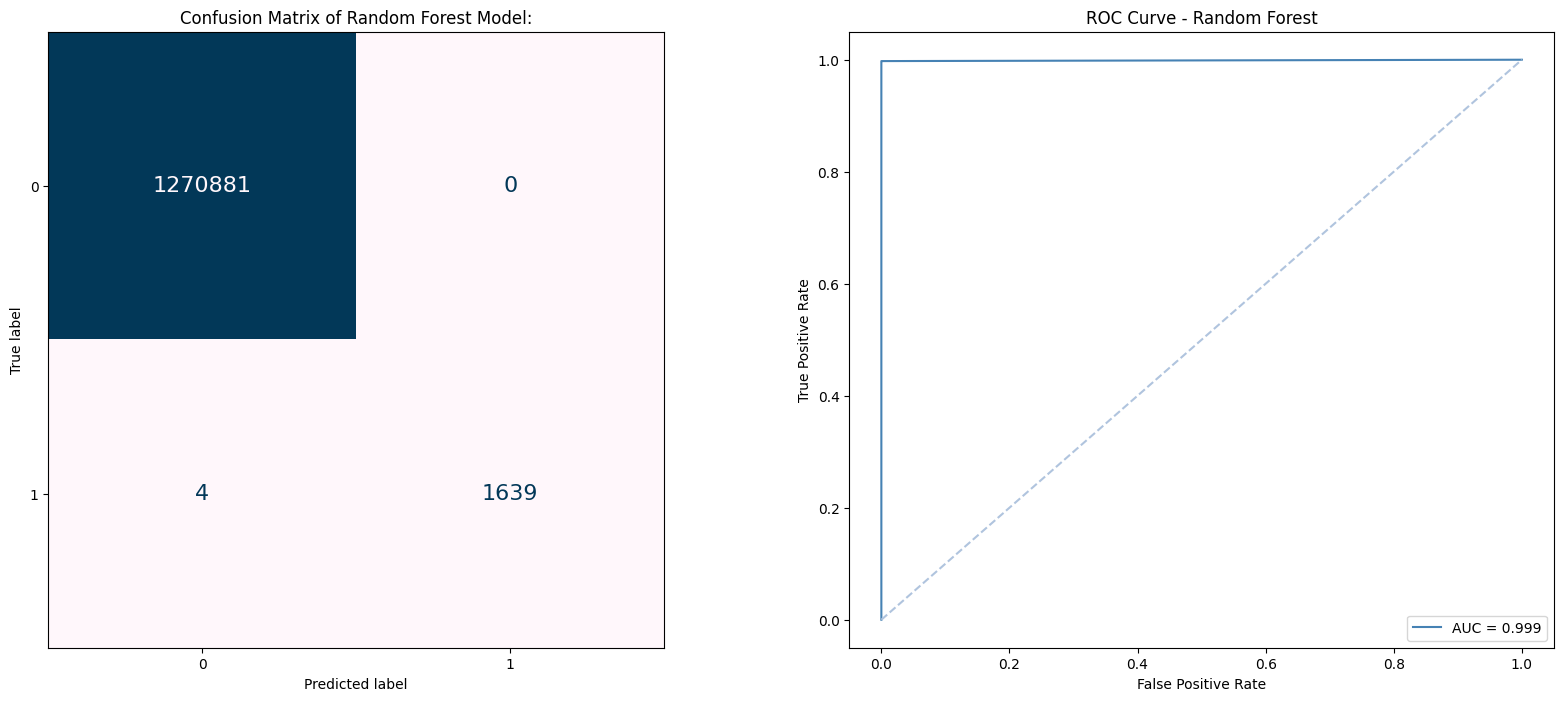

In [88]:
y_pred = rf_y_pred
y_pred_score = rf_y_pred_score

fig, ax = plt.subplots(1, 2, figsize=(20,8))
ax[0].set_title('Confusion Matrix of Random Forest Model:')
ConfusionMatrixDisplay.from_predictions(y_test, rf_y_pred, colorbar=False, values_format='', cmap='PuBu', ax=ax[0],text_kw={'fontsize': 16})
ax[0].grid(False)


fpr, tpr, thresholds = roc_curve(y_test, rf_y_pred_score)
roc_auc = auc(fpr, tpr)                       
ax[1].set_title('ROC Curve - Random Forest')
ax[1].plot(fpr, tpr, label = 'AUC = %0.3f' % roc_auc, c='steelblue')
ax[1].plot([0,1],[0,1],'--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

Text(0.5, 0, 'False Positive Rate')

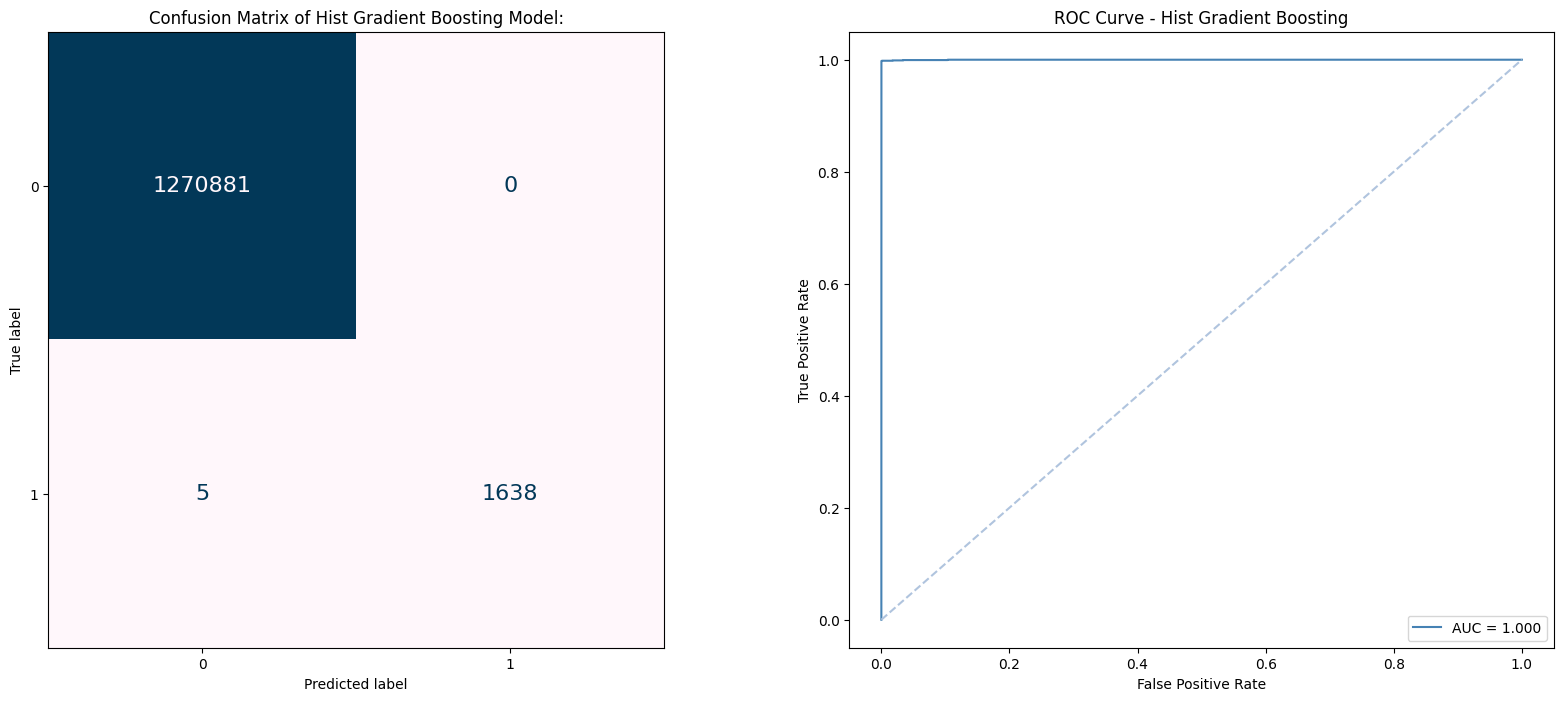

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20,8))
ax[0].set_title('Confusion Matrix of Hist Gradient Boosting Model:')
ConfusionMatrixDisplay.from_predictions(y_test, hgb_y_pred, colorbar=False, values_format='', cmap='PuBu', ax=ax[0],text_kw={'fontsize': 16})
ax[0].grid(False)


fpr, tpr, thresholds = roc_curve(y_test, hgb_y_pred_score)
roc_auc = auc(fpr, tpr)                       
ax[1].set_title('ROC Curve - Hist Gradient Boosting')
ax[1].plot(fpr, tpr, label = 'AUC = %0.3f' % roc_auc, c='steelblue')
ax[1].plot([0,1],[0,1],'--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

Text(0.5, 0, 'False Positive Rate')

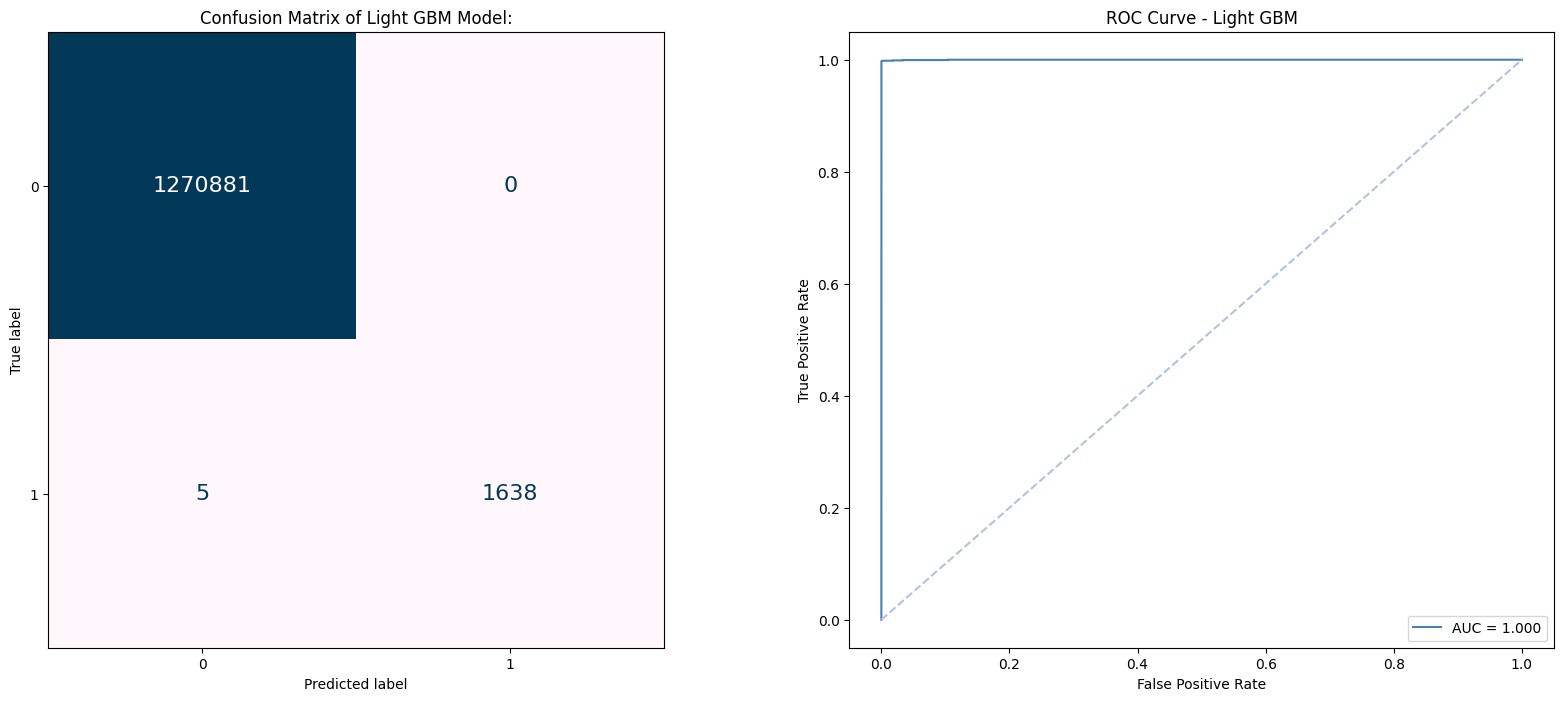

In [87]:
fig, ax = plt.subplots(1, 2, figsize=(20,8))
ax[0].set_title('Confusion Matrix of Light GBM Model:')
ConfusionMatrixDisplay.from_predictions(y_test, hgb_y_pred, colorbar=False, values_format='', cmap='PuBu', ax=ax[0],text_kw={'fontsize': 16})
ax[0].grid(False)


fpr, tpr, thresholds = roc_curve(y_test, hgb_y_pred_score)
roc_auc = auc(fpr, tpr)                       
ax[1].set_title('ROC Curve - Light GBM')
ax[1].plot(fpr, tpr, label = 'AUC = %0.3f' % roc_auc, c='steelblue')
ax[1].plot([0,1],[0,1],'--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')